In [98]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [99]:
df=pd.read_csv('/content/drive/MyDrive/Datasets/Social_Network_Ads.csv')

In [100]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


<Axes: ylabel='EstimatedSalary'>

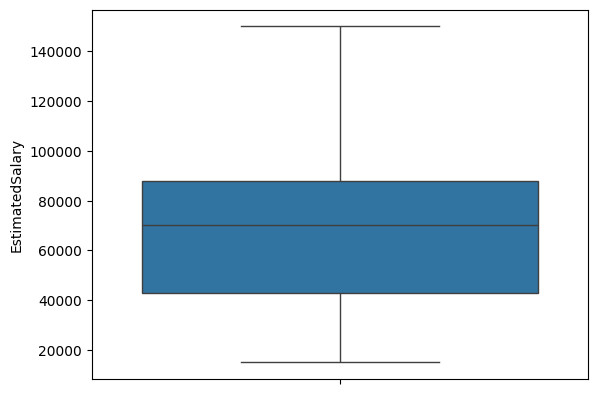

In [102]:
import seaborn as sns

sns.boxplot(df['EstimatedSalary'])

<Axes: ylabel='Age'>

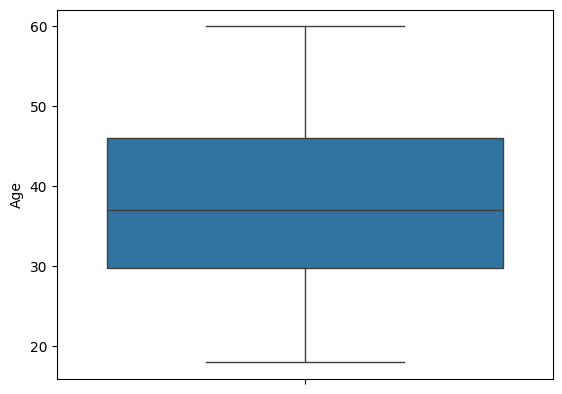

In [103]:
sns.boxplot(df['Age'])

In [104]:
X=df[['Age','EstimatedSalary']] #df.iloc[:,[2,3]].values
y=df['Purchased'] #df.iloc[:,-1].values


In [105]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [106]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

#**Define Base Models**

In [107]:
base_models=[
    ('lr',LogisticRegression()),
    ('knn',KNeighborsClassifier(n_neighbors=5)),
    ('dt',DecisionTreeClassifier(max_depth=3))
]

#**Define Meta Model**

Meta model decides how to combine predictions

It takes one model from base models and combine other models

In [108]:
meta_model=LogisticRegression()


In [109]:
classifier=StackingClassifier(estimators=base_models,
                              final_estimator=meta_model,
                              cv=5)
classifier.fit(X_train,y_train)

StackingClassifier(cv=5,
                   estimators=[('lr', LogisticRegression()),
                               ('knn', KNeighborsClassifier()),
                               ('dt', DecisionTreeClassifier(max_depth=3))],
                   final_estimator=LogisticRegression())

In [110]:
y_pred=classifier.predict(X_test)

In [111]:
acc=accuracy_score(y_test,y_pred)
acc

0.9

In [112]:
y_pred_lr=classifier.named_estimators_['lr'].predict(X_test)
y_pred_knn=classifier.named_estimators_['knn'].predict(X_test)
y_pred_dt=classifier.named_estimators_['dt'].predict(X_test)


In [113]:
acc_lr=accuracy_score(y_test,y_pred_lr)
acc_lr

0.8625

In [114]:
acc_knn=accuracy_score(y_test,y_pred_knn)
acc_knn

0.9125

In [115]:
acc_dt=accuracy_score(y_test,y_pred_dt)
acc_dt


0.9125

In [116]:
df=pd.read_csv('/content/drive/MyDrive/Datasets/train_u6lujuX_CVtuZ9i.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [118]:
# Categorical - fill with mode
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical - fill with median
num_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Credit_History (important feature) - fill with mode
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)


/tmp/ipython-input-4120887670.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-4120887670.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [119]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])


In [120]:
df = pd.get_dummies(df, columns=['Dependents', 'Property_Area'], drop_first=True)


In [121]:
X = df.drop(columns=['Loan_Status', 'Loan_ID'])
y = df['Loan_Status']


In [122]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [123]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

In [124]:
base_models = [
    ('lr', Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=3000))
    ])),

    ('dt', DecisionTreeClassifier(random_state=42)),

    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )),

    ('svm', Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', probability=True))
    ]))
]


In [125]:
meta_model=LogisticRegression()

In [126]:
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough=False
)


In [127]:
stacking_model.fit(X_train, y_train)


StackingClassifier(cv=5,
                   estimators=[('lr',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('lr',
                                                 LogisticRegression(max_iter=3000))])),
                               ('dt', DecisionTreeClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('svm',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('svm',
                                                 SVC(probability=True))]))],
                   final_estimator=LogisticRegression())

In [128]:
y_pred_stack = stacking_model.predict(X_test)

stacking_accuracy = accuracy_score(y_test, y_pred_stack)
stacking_accuracy


0.7886178861788617